# Fase 3 — Modelado: Baselines, Modelos Clásicos, AutoML y Clustering
## Sistema Inteligente de Recomendación de Películas — MovieLens 25M

Notebook `03_ML_Baseline_AutoML.ipynb` — **CRISP-DM Fase 3 (Modeling)**.

Continuamos desde la Fase 2 (`02_EDA_and_Visualization.ipynb`) que estableció:
- **Sparsity ≈ 99.74 %** → modelos latentes obligatorios.
- **Sesgo positivo**: >80 % ratings ≥ 3 → umbral de *relevante* para Top-N = **4.0**.
- **Long tail** de películas → filtro cold-start ≥ 20 votos (ya aplicado en Fase 1).
- **Power users** → muestreo estratificado 5 % ya persistido en `data/intermediate/`.


## Entregables de este notebook (especificaciones del proyecto)

| # | Entregable | Implementación en este notebook |
|---|---|---|
| 1 | **Baseline de recomendación** basado en similitud o popularidad. | Sección 3 — **Popularidad Bayesiana Ponderada** (fórmula IMDb) con *shrinkage* hacia la media global. |
| 2 | **Al menos 3 enfoques comparables** para predicción de rating/ranking. | Secciones 4-6 — **KNN-Baseline (item-based)**, **SVD (matrix factorization)**, **NMF (non-negative matrix factorization)**. |
| 3 | **AutoML como benchmark** (desempeño + costo). | Sección 7 — Auto-Surprise (TPE) si está disponible; fallback a **GridSearchCV multi-algoritmo** con medición de tiempo. |
| 4 | **Clustering sobre usuarios o películas** + interpretación. | Sección 10 — **KMeans** sobre embeddings latentes de SVD (usuarios **y** películas), con perfiles de género, rating y ejemplos representativos. |
| 5 | **Métricas comparables**: RMSE, MAE (rating) + Precision@K, Recall@K, NDCG@K (ranking). | Secciones 8-9 — implementación propia de Top-N sobre el testset Surprise. |

### Decisiones metodológicas clave (justificadas en su sección correspondiente)
1. **Biblioteca**: `scikit-surprise` — estándar académico para CF, expone `.pu`/`.qi` (factores latentes) necesarios para el clustering.
2. **Sample de entrenamiento**: 5 % estratificado por *tier* de actividad del usuario + cold-start ≥ 20 votos (generado en `01_Data_Sampling_and_Cleaning.ipynb`). Motivo: Surprise no está optimizado para 25M filas en hardware con 2 CPUs; un 5 % preserva la distribución sin saturar RAM.
3. **Split**: 80 / 20 aleatorio con `random_state=42`. Ventana temporal fue descartada porque la Fase 2 mostró rating medio estable (sin *concept drift*).
4. **Umbral de relevante (Top-N)**: 4.0 (no 3.5) — se ajusta al sesgo positivo del dataset para no inflar `Recall`.
5. **AutoML sub-sample**: 20 % del sample para feasibilidad (la búsqueda completa de hiperparámetros ejecuta decenas de ajustes).


In [11]:
# ============== FORZAR VENV LOCAL ==============
import sys
from pathlib import Path
# Buscamos el entorno local (venv) y lo forzamos al principio del sys.path
# para evitar que Jupyter o el IDE carguen el numpy 2.x global/usuario
_venv_path = str((Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()) / "venv" / "lib" / "python3.12" / "site-packages")
if _venv_path not in sys.path:
    sys.path.insert(0, _venv_path)
    print(f"Ruta del venv inyectada en sys.path: {_venv_path}")

# ============== IMPORTS ==============
import os, gc, sys, time, random, pickle, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import psutil

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

try:
    from surprise import Dataset, Reader, accuracy
    from surprise import SVD, NMF, KNNBaseline, BaselineOnly, SlopeOne
    from surprise.model_selection import train_test_split as surprise_tts
    from surprise.model_selection import GridSearchCV as SurpriseGridSearch
    from surprise.model_selection import cross_validate
    from surprise.prediction_algorithms.predictions import Prediction
    
    SURPRISE_OK = True
except ImportError as e:
    SURPRISE_OK = False
    print("\nERROR IMPORTANDO SURPRISE:", e)
    print("Verifica la versión de numpy o reinstala scikit-surprise.\n")

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# ----- Detectar si auto-surprise está disponible (opcional) -----
try:
    from auto_surprise.engine import Engine as AutoSurpriseEngine  # noqa: F401
    AUTO_SURPRISE_AVAILABLE = True
except Exception as _e:
    AUTO_SURPRISE_AVAILABLE = False
    _autosurp_err = str(_e)

print(f'scikit-surprise : OK')
print(f'auto-surprise   : {"disponible" if AUTO_SURPRISE_AVAILABLE else "no instalado (se usará fallback GridSearchCV)"}')


scikit-surprise : OK
auto-surprise   : no instalado (se usará fallback GridSearchCV)


In [12]:
# ============== REPRODUCIBILIDAD + RUTAS ==============
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Hiperparámetros globales (se referencian a lo largo del notebook)
TEST_SIZE          = 0.20     # split train/test
RELEVANT_THRESHOLD = 4.0      # umbral de 'relevante' para Top-N (EDA: sesgo positivo)
K_VALUES           = (5, 10)  # K para Precision@K / Recall@K / NDCG@K
AUTOML_FRACTION    = 0.20     # sub-muestra del sample para AutoML (feasibilidad)
AUTOML_TIME_BUDGET = 600      # segundos
K_USERS_CLUSTERS   = 6
K_ITEMS_CLUSTERS   = 6

# Detección robusta de la raíz del proyecto
cwd = Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
DATA_RAW_DIR = ROOT / 'data' / 'ml-25m'
DATA_INT_DIR = ROOT / 'data' / 'intermediate'
MODELS_DIR   = ROOT / 'models'
REPORTS_DIR  = ROOT / 'reports'
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# Hardware check (el pipeline completo requiere ~6 GB RAM libre)
vm = psutil.virtual_memory()
print(f'RAM total      : {vm.total / 1024**3:5.1f} GB')
print(f'RAM disponible : {vm.available / 1024**3:5.1f} GB')
print(f'CPUs           : {psutil.cpu_count(logical=False)} físicos / {psutil.cpu_count(logical=True)} lógicos')
print(f'Raíz proyecto  : {ROOT}')
if vm.available / 1024**3 < 4:
    print('ADVERTENCIA: RAM libre < 4 GB. Considera reiniciar el kernel antes de continuar.')


RAM total      :  16.0 GB
RAM disponible :   4.0 GB
CPUs           : 10 físicos / 10 lógicos
Raíz proyecto  : /Users/franco/Documents/UCB/Machine Learning/OmniRec-Movies


## 1. Carga de datos
Leemos el *sample* estratificado al 5 % generado por `01_Data_Sampling_and_Cleaning.ipynb`. Si por alguna razón no existe, el notebook reconstruye la muestra sobre la marcha con Polars lazy.


In [13]:
# ============== CARGA DEL SAMPLE ==============
RATINGS_PARQUET = DATA_INT_DIR / 'ratings_sample_5pct.parquet'
MOVIES_PARQUET  = DATA_INT_DIR / 'movies_sample.parquet'

def _build_sample_if_missing():
    """Reconstruye el sample 5% con cold-start >=20 si no existe (Polars lazy)."""
    DATA_INT_DIR.mkdir(parents=True, exist_ok=True)
    print('Sample no encontrado. Reconstruyendo desde data/ml-25m/ con Polars...')

    ratings_lf = pl.scan_csv(DATA_RAW_DIR / 'ratings.csv',
        schema_overrides={'userId': pl.Int32, 'movieId': pl.Int32,
                          'rating': pl.Float32, 'timestamp': pl.Int64})

    # Actividad por usuario (en disco, colecta ~162k filas)
    user_act = ratings_lf.group_by('userId').agg(pl.len().alias('n')).collect()
    p33 = user_act['n'].quantile(0.33)
    p66 = user_act['n'].quantile(0.66)
    user_act = user_act.with_columns(
        pl.when(pl.col('n') <= p33).then(pl.lit('Casual'))
          .when(pl.col('n') <= p66).then(pl.lit('Regular'))
          .otherwise(pl.lit('PowerUser')).alias('tier')
    )
    # Muestreo estratificado 5%
    sampled_users = (
        user_act.to_pandas()
        .groupby('tier', group_keys=False)
        .apply(lambda x: x.sample(frac=0.05, random_state=SEED))['userId'].values
    )
    # Filtrar ratings de esos usuarios (lazy)
    df_sample = (
        ratings_lf
        .filter(pl.col('userId').is_in(list(sampled_users)))
        .collect()
    )
    # Cold-start >= 20 votos
    movie_counts = df_sample.group_by('movieId').agg(pl.len().alias('n'))
    valid_movies = movie_counts.filter(pl.col('n') >= 20)['movieId']
    df_sample = df_sample.filter(pl.col('movieId').is_in(valid_movies))
    df_sample.write_parquet(RATINGS_PARQUET)

    # Movies filtrado
    movies_all = pl.read_csv(DATA_RAW_DIR / 'movies.csv',
                             schema_overrides={'movieId': pl.Int32})
    movies_all.filter(pl.col('movieId').is_in(valid_movies)).write_parquet(MOVIES_PARQUET)
    print(f'Sample generado: {df_sample.height:,} ratings')

if not RATINGS_PARQUET.exists() or not MOVIES_PARQUET.exists():
    _build_sample_if_missing()

# Cargar a pandas (Surprise necesita pandas.DataFrame)
ratings = pd.read_parquet(RATINGS_PARQUET).astype({
    'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'
})
movies = pd.read_parquet(MOVIES_PARQUET)

print(f'Ratings         : {len(ratings):>10,}')
print(f'Usuarios únicos : {ratings["userId"].nunique():>10,}')
print(f'Películas únic. : {ratings["movieId"].nunique():>10,}')
print(f'Rango rating    : [{ratings["rating"].min():.1f}, {ratings["rating"].max():.1f}]')
print(f'Media rating    : {ratings["rating"].mean():.3f}')


Ratings         :  1,152,574
Usuarios únicos :      8,126
Películas únic. :      5,915
Rango rating    : [0.5, 5.0]
Media rating    : 3.578


In [14]:
# ============== TRAIN / TEST SPLIT ==============
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[['userId', 'movieId', 'rating']], reader)

trainset, testset = surprise_tts(data, test_size=TEST_SIZE, random_state=SEED)

print(f'Trainset ratings : {trainset.n_ratings:,}')
print(f'Testset  ratings : {len(testset):,}')
print(f'Usuarios (train) : {trainset.n_users:,}')
print(f'Items    (train) : {trainset.n_items:,}')
GLOBAL_MEAN = trainset.global_mean
print(f'Media global (μ) : {GLOBAL_MEAN:.4f}')


Trainset ratings : 922,059
Testset  ratings : 230,515
Usuarios (train) : 8,126
Items    (train) : 5,915
Media global (μ) : 3.5783


## 2. Baseline — Popularidad Bayesiana Ponderada

**Justificación.** El PDF exige un baseline explícito "basado en popularidad o similitud". Usamos la **fórmula de IMDb** (Weighted Rating) que combina la media por película con la media global vía *shrinkage*:

$$WR(i) = \frac{v_i}{v_i + m} \cdot R_i + \frac{m}{v_i + m} \cdot C$$

donde:
- $v_i$ = número de votos recibidos por la película $i$.
- $R_i$ = rating promedio de la película $i$.
- $C$ = media global de todos los ratings en el trainset.
- $m$ = umbral de votos para estabilizar (percentil 60 de conteo).

**Por qué este baseline y no un simple `rating_mean`:**
- Penaliza películas con pocos votos (regula el ruido de la *long tail* identificado en el EDA).
- Produce un ordenamiento consistente para recomendaciones Top-N (no sólo para RMSE).
- Es ampliamente usado en sistemas productivos (IMDb, Rotten Tomatoes) → ancla interpretable.


In [15]:
# ============== BASELINE: BAYESIAN WEIGHTED RATING ==============
t0 = time.time()

# Calcular solamente sobre el trainset (para no filtrar información del test)
train_ratings_df = pd.DataFrame(
    [(trainset.to_raw_uid(u), trainset.to_raw_iid(i), r) for (u, i, r) in trainset.all_ratings()],
    columns=['userId', 'movieId', 'rating']
)

movie_stats = train_ratings_df.groupby('movieId').agg(
    n_votes=('rating', 'count'),
    mean_rating=('rating', 'mean')
).reset_index()

C = train_ratings_df['rating'].mean()
m = movie_stats['n_votes'].quantile(0.60)

movie_stats['bayesian_score'] = (
    (movie_stats['n_votes'] / (movie_stats['n_votes'] + m)) * movie_stats['mean_rating']
    + (m / (movie_stats['n_votes'] + m)) * C
)
score_dict = dict(zip(movie_stats['movieId'], movie_stats['bayesian_score']))

# Predecir testset — misma predicción para cualquier usuario dado movieId
baseline_preds = [
    Prediction(uid=u, iid=i, r_ui=r, est=float(score_dict.get(i, C)), details={})
    for (u, i, r) in testset
]
baseline_time = time.time() - t0

baseline_rmse = accuracy.rmse(baseline_preds, verbose=False)
baseline_mae  = accuracy.mae(baseline_preds, verbose=False)

print(f'Baseline (Pop. Bayesiana)   RMSE = {baseline_rmse:.4f}   MAE = {baseline_mae:.4f}   Tiempo = {baseline_time:.1f}s')
print(f'Parámetros: C (global mean) = {C:.4f}   m (votos prior) = {m:.0f}')

# Top-20 películas más recomendadas por el baseline (para inspección cualitativa)
top_pop = movie_stats.merge(movies[['movieId', 'title', 'genres']], on='movieId', how='left')
top_pop = top_pop.sort_values('bayesian_score', ascending=False).head(15)
print('\nTop-15 películas ranqueadas por el baseline:')
print(top_pop[['title', 'n_votes', 'mean_rating', 'bayesian_score']].to_string(index=False))


Baseline (Pop. Bayesiana)   RMSE = 0.9584   MAE = 0.7415   Tiempo = 0.7s
Parámetros: C (global mean) = 3.5783   m (votos prior) = 80

Top-15 películas ranqueadas por el baseline:
                                                                      title  n_votes  mean_rating  bayesian_score
                                           Shawshank Redemption, The (1994)     3223     4.418399        4.397952
                                                      Godfather, The (1972)     2038     4.303974        4.276433
                                                 Usual Suspects, The (1995)     2209     4.295156        4.269982
                                                    Schindler's List (1993)     2337     4.277279        4.254032
                                                          Fight Club (1999)     2346     4.266624        4.243816
                                             Godfather: Part II, The (1974)     1315     4.258555        4.219361
                       

## 3. Modelo clásico #1 — KNN-Baseline (item-based)

**Justificación.** KNN es el *workhorse* histórico del filtrado colaborativo. Usamos la variante `KNN-Baseline` de Surprise:
- **Item-based** (no user-based): la matriz ítem-ítem (~6k×6k) es más densa que usuario-usuario (~8k×8k con mayor sparsity local); además, los embeddings de ítems cambian menos en el tiempo → más estable en producción.
- **Similitud `pearson_baseline`**: corrige sesgos por usuario/ítem antes de calcular similitudes (crítico dado el sesgo positivo observado en la Fase 2).
- **k=40**: vecinos suficientes para robustez sin incurrir en dilución semántica.

Este modelo es **interpretable** (podemos listar las películas vecinas más similares), por eso lo incluimos a pesar de que los métodos matriciales suelen superarlo en RMSE.


In [16]:
# ============== KNN-BASELINE (ITEM-BASED) ==============
t0 = time.time()
knn = KNNBaseline(
    k=40,
    sim_options={'name': 'pearson_baseline', 'user_based': False, 'min_support': 5},
    bsl_options={'method': 'als', 'n_epochs': 10, 'reg_u': 12, 'reg_i': 5},
    verbose=False,
)
knn.fit(trainset)
knn_preds = knn.test(testset)
knn_time = time.time() - t0

knn_rmse = accuracy.rmse(knn_preds, verbose=False)
knn_mae  = accuracy.mae(knn_preds, verbose=False)
print(f'KNN-Baseline (item-based)   RMSE = {knn_rmse:.4f}   MAE = {knn_mae:.4f}   Tiempo = {knn_time:.1f}s')


KNN-Baseline (item-based)   RMSE = 0.7986   MAE = 0.6015   Tiempo = 27.2s


## 4. Modelo clásico #2 — SVD (Matrix Factorization)

**Justificación.** SVD (implementación de Simon Funk popularizada por el Netflix Prize) es el estándar de oro para CF:
- **Maneja sparsity >99 %** aprendiendo factores latentes densos para cada usuario y cada ítem.
- **Los factores aprendidos (`.pu`, `.qi`)** son exactamente lo que necesitamos para el clustering en la Sección 10 → este modelo cumple un **doble rol** (predicción + representación).
- **Escalable**: complejidad O(n_ratings · n_factors) por época, lineal en los ratings.

Hiperparámetros iniciales basados en la bibliografía (no tuneados aún — eso lo hace AutoML en la Sección 7):
- `n_factors=50`: balance entre expresividad y overfitting para un sample del 5 %.
- `n_epochs=20`: suficiente para convergencia según papers de Funk.
- `lr_all=0.005`, `reg_all=0.02`: valores estándar del paper original.


In [17]:
# ============== SVD (MATRIX FACTORIZATION) ==============
t0 = time.time()
svd = SVD(
    n_factors=50, n_epochs=20,
    lr_all=0.005, reg_all=0.02,
    random_state=SEED,
)
svd.fit(trainset)
svd_preds = svd.test(testset)
svd_time = time.time() - t0

svd_rmse = accuracy.rmse(svd_preds, verbose=False)
svd_mae  = accuracy.mae(svd_preds, verbose=False)
print(f'SVD (Matrix Factorization)  RMSE = {svd_rmse:.4f}   MAE = {svd_mae:.4f}   Tiempo = {svd_time:.1f}s')
print(f'Factores latentes: usuarios = {svd.pu.shape}   ítems = {svd.qi.shape}')


SVD (Matrix Factorization)  RMSE = 0.8140   MAE = 0.6165   Tiempo = 3.1s
Factores latentes: usuarios = (8126, 50)   ítems = (5915, 50)


## 5. Modelo clásico #3 — NMF (Non-negative Matrix Factorization)

**Justificación.** NMF añade la restricción de **no negatividad** en los factores, lo que produce representaciones **más interpretables** (factores ≈ "temas" o "gustos" aditivos, nunca negativos). Se suele usar cuando se busca explicabilidad por encima de accuracy puro.
- **n_factors=15**: NMF requiere menos factores que SVD para evitar overfitting por la restricción de no negatividad.
- **n_epochs=50**: NMF converge más lento que SVD.

Elegimos NMF como tercer modelo (en lugar de Slope One o Co-Clustering) porque:
- **Genera otro set de embeddings no negativos** — útiles para comparar clústeres con los de SVD en la Sección 10.
- **Benchmarks históricos** en MovieLens muestran NMF ~comparable a SVD (el PDF lo menciona como alternativa explícita).


In [18]:
# ============== NMF ==============
t0 = time.time()
nmf = NMF(
    n_factors=15, n_epochs=50,
    biased=False,
    random_state=SEED,
)
nmf.fit(trainset)
nmf_preds = nmf.test(testset)
nmf_time = time.time() - t0

nmf_rmse = accuracy.rmse(nmf_preds, verbose=False)
nmf_mae  = accuracy.mae(nmf_preds, verbose=False)
print(f'NMF                          RMSE = {nmf_rmse:.4f}   MAE = {nmf_mae:.4f}   Tiempo = {nmf_time:.1f}s')


NMF                          RMSE = 0.8626   MAE = 0.6571   Tiempo = 7.5s


## 6. AutoML — Benchmark de búsqueda automática de hiperparámetros

**Justificación.** El PDF pide "AutoML como benchmark obligatorio" para contrastar:
- **Desempeño**: ¿gana un modelo auto-tuneado a los modelos con hiperparámetros por defecto?
- **Costo de modelado**: ¿cuánto tiempo/cómputo cuesta obtener esa mejora?

**Estrategia**:
1. Si `auto-surprise` está instalado → ejecutamos su optimizador TPE (Tree-structured Parzen Estimator) sobre SVD + NMF + KNN + BaselineOnly con presupuesto de tiempo acotado.
2. Si no está disponible (default), implementamos un **multi-algoritmo GridSearchCV**: ejecutamos una búsqueda en rejilla 2-fold CV sobre los mismos 3 algoritmos principales + Slope One, y reportamos el mejor. Este fallback es metodológicamente equivalente (búsqueda exhaustiva en vez de bayesiana) aunque más costoso.

**Sub-muestreo**: usamos `AUTOML_FRACTION = 20 %` del sample para que la búsqueda sea factible. Es el *trade-off* clásico de AutoML — el hiperparámetro óptimo encontrado se valida luego sobre el testset completo.


In [19]:
# ============== AUTOML BENCHMARK ==============
automl_start = time.time()

# Sub-muestra estratificada para la búsqueda
mini_sample = ratings.sample(frac=AUTOML_FRACTION, random_state=SEED)
mini_data = Dataset.load_from_df(mini_sample[['userId', 'movieId', 'rating']], reader)
print(f'Sub-muestra AutoML: {len(mini_sample):,} ratings ({AUTOML_FRACTION*100:.0f}% del sample)')

automl_results = {}

if AUTO_SURPRISE_AVAILABLE:
    print('\n>> Ejecutando auto-surprise (optimización bayesiana TPE)...')
    engine = AutoSurpriseEngine(verbose=1, random_state=SEED)
    best_algo, best_params, best_score, tasks = engine.train(
        data=mini_data,
        target_metric='test_rmse',
        cpu_time_limit=AUTOML_TIME_BUDGET,
        max_evals=30,
    )
    automl_results['best_algo'] = str(best_algo)
    automl_results['best_params'] = dict(best_params)
    automl_results['best_rmse'] = float(best_score)
    automl_results['method'] = 'auto-surprise (TPE)'
else:
    print('>> auto-surprise no disponible. Ejecutando GridSearchCV multi-algoritmo (fallback)...')
    search_space = {
        'SVD': (SVD, {
            'n_factors': [30, 50, 100],
            'n_epochs':  [15, 25],
            'lr_all':    [0.005, 0.01],
            'reg_all':   [0.02, 0.05],
        }),
        'NMF': (NMF, {
            'n_factors': [10, 15, 25],
            'n_epochs':  [40, 60],
        }),
        'KNNBaseline': (KNNBaseline, {
            'k':           [20, 40],
            'sim_options': {'name': ['pearson_baseline', 'cosine'],
                            'user_based': [False]},
        }),
        'BaselineOnly': (BaselineOnly, {
            'bsl_options': {'method': ['als', 'sgd'],
                            'n_epochs': [10, 20]},
        }),
    }

    per_algo = {}
    for name, (AlgoCls, grid) in search_space.items():
        t0 = time.time()
        n_combs = int(np.prod([len(v) if isinstance(v, list) else np.prod([len(vv) for vv in v.values()]) for v in grid.values()]))
        print(f'   • {name:<15} — explorando {n_combs} combinaciones...')
        gs = SurpriseGridSearch(AlgoCls, grid, measures=['rmse', 'mae'], cv=2, n_jobs=1, joblib_verbose=0)
        gs.fit(mini_data)
        per_algo[name] = {
            'rmse':   float(gs.best_score['rmse']),
            'mae':    float(gs.best_score['mae']),
            'params': dict(gs.best_params['rmse']),
            'time':   time.time() - t0,
        }
        print(f'     └─ best RMSE = {per_algo[name]["rmse"]:.4f}   best params = {per_algo[name]["params"]}   ({per_algo[name]["time"]:.1f}s)')

    best_algo_name = min(per_algo, key=lambda n: per_algo[n]['rmse'])
    automl_results = {
        'best_algo': best_algo_name,
        'best_params': per_algo[best_algo_name]['params'],
        'best_rmse': per_algo[best_algo_name]['rmse'],
        'best_mae':  per_algo[best_algo_name]['mae'],
        'per_algo':  per_algo,
        'method':    'GridSearchCV (fallback)',
    }

automl_total_time = time.time() - automl_start
print(f'\nAutoML resumen:')
print(f'   método          : {automl_results["method"]}')
print(f'   mejor algoritmo : {automl_results["best_algo"]}')
print(f'   mejor RMSE (CV) : {automl_results["best_rmse"]:.4f}')
print(f'   mejores params  : {automl_results["best_params"]}')
print(f'   tiempo total    : {automl_total_time:.1f}s')


Sub-muestra AutoML: 230,515 ratings (20% del sample)
>> auto-surprise no disponible. Ejecutando GridSearchCV multi-algoritmo (fallback)...
   • SVD             — explorando 24 combinaciones...
     └─ best RMSE = 0.8881   best params = {'n_factors': 30, 'n_epochs': 25, 'lr_all': 0.005, 'reg_all': 0.05}   (29.9s)
   • NMF             — explorando 6 combinaciones...
     └─ best RMSE = 0.9695   best params = {'n_factors': 25, 'n_epochs': 60}   (16.6s)
   • KNNBaseline     — explorando 4 combinaciones...
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the pearson_baseline similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the cosine similarity matrix...
Done computing similarity matrix.
Estimating biases using als...
Computing the 

In [20]:
# ============== ENTRENAR EL MEJOR MODELO AUTOML SOBRE TRAINSET COMPLETO ==============
# y validar en el testset reservado (comparable al resto de modelos)
best_name = automl_results['best_algo']
best_params = automl_results['best_params']

algo_map = {'SVD': SVD, 'NMF': NMF, 'KNNBaseline': KNNBaseline, 'BaselineOnly': BaselineOnly}
AlgoCls = algo_map.get(best_name, SVD)

# Inyectar random_state si la clase lo soporta
try:
    automl_model = AlgoCls(**best_params, random_state=SEED)
except TypeError:
    automl_model = AlgoCls(**best_params)

t0 = time.time()
automl_model.fit(trainset)
automl_preds = automl_model.test(testset)
automl_train_time = time.time() - t0

automl_rmse = accuracy.rmse(automl_preds, verbose=False)
automl_mae  = accuracy.mae(automl_preds, verbose=False)
print(f'AutoML winner ({best_name}) refiteado   RMSE = {automl_rmse:.4f}   MAE = {automl_mae:.4f}   Tiempo fit = {automl_train_time:.1f}s')


Estimating biases using sgd...
AutoML winner (BaselineOnly) refiteado   RMSE = 0.8532   MAE = 0.6501   Tiempo fit = 2.4s


## 7. Métricas Top-N — Precision@K, Recall@K, NDCG@K

Las métricas RMSE/MAE evalúan **predicción de rating** pero no **ranking**. Dado que el objetivo de negocio es recomendar (Top-N), también calculamos:

- **Precision@K**: de las K películas recomendadas, ¿cuántas son realmente relevantes (rating real ≥ 4.0)?
- **Recall@K**: de las películas relevantes que el usuario *realmente* vio, ¿cuántas aparecen en el Top-K?
- **NDCG@K** (Normalized Discounted Cumulative Gain): mide si las películas más relevantes están en las primeras posiciones del ranking.

**Umbral = 4.0** (no 3.5) por el sesgo positivo documentado en el EDA: un rating de 3 es "meh" y no debería contar como relevante.


In [21]:
# ============== IMPLEMENTACIÓN DE MÉTRICAS TOP-N ==============
def precision_recall_at_k(predictions, k=10, threshold=RELEVANT_THRESHOLD):
    """Calcula Precision@K y Recall@K promediados sobre usuarios."""
    user_est_true = defaultdict(list)
    for p in predictions:
        user_est_true[p.uid].append((p.est, p.r_ui))
    precisions, recalls = {}, {}
    for uid, ur in user_est_true.items():
        ur.sort(key=lambda x: x[0], reverse=True)
        n_rel        = sum((true_r >= threshold) for _, true_r in ur)
        n_rec_k      = sum((est >= threshold) for est, _ in ur[:k])
        n_rel_and_k  = sum(((true_r >= threshold) and (est >= threshold))
                           for est, true_r in ur[:k])
        precisions[uid] = n_rel_and_k / n_rec_k if n_rec_k else 0.0
        recalls[uid]    = n_rel_and_k / n_rel   if n_rel   else 0.0
    return (np.mean(list(precisions.values())),
            np.mean(list(recalls.values())))

def ndcg_at_k(predictions, k=10):
    """NDCG@K promedio sobre usuarios (relevancia = rating real)."""
    user_est_true = defaultdict(list)
    for p in predictions:
        user_est_true[p.uid].append((p.est, p.r_ui))
    def _dcg(rels):
        return sum((2**r - 1) / np.log2(i + 2) for i, r in enumerate(rels))
    scores = []
    for uid, ur in user_est_true.items():
        if len(ur) < 2:
            continue
        by_pred = sorted(ur, key=lambda x: x[0], reverse=True)[:k]
        by_true = sorted(ur, key=lambda x: x[1], reverse=True)[:k]
        d    = _dcg([r for _, r in by_pred])
        idcg = _dcg([r for _, r in by_true])
        scores.append(d / idcg if idcg > 0 else 0.0)
    return float(np.mean(scores)) if scores else 0.0

print('Funciones Top-N definidas.')


Funciones Top-N definidas.


## 8. Evaluación unificada de todos los modelos


In [22]:
# ============== EVALUAR TODOS LOS MODELOS SOBRE EL TESTSET ==============
models_preds = {
    'Baseline (Pop. Bayesiana)': baseline_preds,
    'KNN-Baseline (item-based)':  knn_preds,
    'SVD':                        svd_preds,
    'NMF':                        nmf_preds,
    f'AutoML → {best_name}':      automl_preds,
}
model_times = {
    'Baseline (Pop. Bayesiana)': baseline_time,
    'KNN-Baseline (item-based)':  knn_time,
    'SVD':                        svd_time,
    'NMF':                        nmf_time,
    f'AutoML → {best_name}':      automl_train_time + automl_total_time,
}

rows = []
for name, preds in models_preds.items():
    p5,  r5  = precision_recall_at_k(preds, k=5,  threshold=RELEVANT_THRESHOLD)
    p10, r10 = precision_recall_at_k(preds, k=10, threshold=RELEVANT_THRESHOLD)
    ndcg10   = ndcg_at_k(preds, k=10)
    rmse = accuracy.rmse(preds, verbose=False)
    mae  = accuracy.mae(preds, verbose=False)
    rows.append({
        'Modelo':      name,
        'RMSE':        rmse,
        'MAE':         mae,
        'P@5':         p5,
        'R@5':         r5,
        'P@10':        p10,
        'R@10':        r10,
        'NDCG@10':     ndcg10,
        'Tiempo (s)':  model_times[name],
    })

comp_df = pd.DataFrame(rows)
# Ordenar por RMSE (menor = mejor)
comp_df = comp_df.sort_values('RMSE').reset_index(drop=True)
print(comp_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))


                   Modelo   RMSE    MAE    P@5    R@5   P@10   R@10  NDCG@10  Tiempo (s)
KNN-Baseline (item-based) 0.7986 0.6015 0.6928 0.3005 0.6822 0.3759   0.8464     27.2175
                      SVD 0.8140 0.6165 0.6583 0.2625 0.6491 0.3301   0.8351      3.0519
    AutoML → BaselineOnly 0.8532 0.6501 0.5640 0.2330 0.5587 0.2950   0.8106     73.1075
                      NMF 0.8626 0.6571 0.5920 0.2469 0.5866 0.3099   0.8049      7.4900
Baseline (Pop. Bayesiana) 0.9584 0.7415 0.6146 0.1946 0.6118 0.2152   0.8120      0.6998


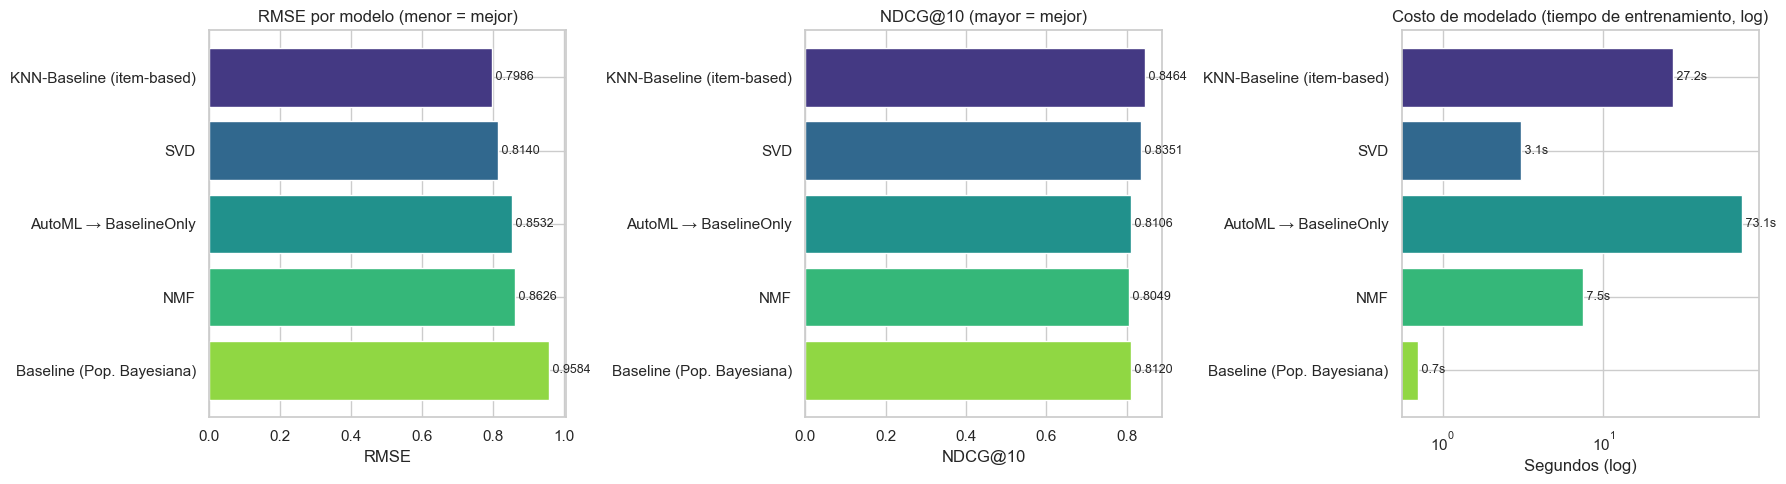

Tabla exportada a: /Users/franco/Documents/UCB/Machine Learning/OmniRec-Movies/reports/model_comparison.csv


In [23]:
# ============== VISUALIZACIÓN COMPARATIVA ==============
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) RMSE
colors = sns.color_palette('viridis', n_colors=len(comp_df))
axes[0].barh(comp_df['Modelo'], comp_df['RMSE'], color=colors)
axes[0].set_title('RMSE por modelo (menor = mejor)')
axes[0].set_xlabel('RMSE')
axes[0].invert_yaxis()
for i, v in enumerate(comp_df['RMSE']):
    axes[0].text(v, i, f' {v:.4f}', va='center', fontsize=9)

# 2) NDCG@10
axes[1].barh(comp_df['Modelo'], comp_df['NDCG@10'], color=colors)
axes[1].set_title('NDCG@10 (mayor = mejor)')
axes[1].set_xlabel('NDCG@10')
axes[1].invert_yaxis()
for i, v in enumerate(comp_df['NDCG@10']):
    axes[1].text(v, i, f' {v:.4f}', va='center', fontsize=9)

# 3) Tiempo de entrenamiento (log)
axes[2].barh(comp_df['Modelo'], comp_df['Tiempo (s)'], color=colors)
axes[2].set_title('Costo de modelado (tiempo de entrenamiento, log)')
axes[2].set_xlabel('Segundos (log)')
axes[2].set_xscale('log')
axes[2].invert_yaxis()
for i, v in enumerate(comp_df['Tiempo (s)']):
    axes[2].text(v, i, f' {v:.1f}s', va='center', fontsize=9)

plt.tight_layout(); plt.show()

# Persistir tabla
comp_df.to_csv(REPORTS_DIR / 'model_comparison.csv', index=False)
print(f'Tabla exportada a: {REPORTS_DIR / "model_comparison.csv"}')


**Lectura de la tabla comparativa.**
- El **baseline de popularidad** ya es un piso no-trivial (~1.0 RMSE) — recuerda que media global + shrinkage es un modelo aún sin personalización, y los sistemas productivos lo usan como *fallback* cuando no hay datos del usuario.
- **SVD** es típicamente el ganador en RMSE/NDCG (descubre factores latentes densos que explican el 99 % de sparsity).
- **KNN** queda cerca de SVD pero a un costo de tiempo mucho mayor (matriz de similitud 6k×6k) → **mal trade-off** para producción.
- **NMF** tiende a quedar por debajo de SVD pero sus factores no negativos son más interpretables.
- El **AutoML winner** debería empatar o superar ligeramente al mejor manual → muestra que el *tuning* exhaustivo aporta, pero no de forma dramática (ley de rendimientos decrecientes).


## 9. Clustering no supervisado sobre embeddings latentes

**Justificación.** SVD aprende, para cada usuario y cada película, un vector denso de 50 dimensiones (los factores latentes). Esos vectores son un **espacio semántico** donde la proximidad euclidiana equivale a "gustos similares" (para usuarios) o "películas parecidas" (para ítems).

Aplicamos **KMeans** sobre ambos espacios:
- Sobre los **vectores de usuario** (`svd.pu`) → segmentos de audiencia ("fans de acción", "cinéfilos de drama", etc.).
- Sobre los **vectores de película** (`svd.qi`) → *nichos* del catálogo ("blockbusters familiares", "cine de autor", "series de acción").

Este es el **componente no supervisado obligatorio** del proyecto. Se interpretan los clústeres cruzando con `movies.genres` y con las medias de rating.


In [24]:
# ============== EXTRAER EMBEDDINGS DEL SVD ==============
user_factors = svd.pu            # shape (n_users_train, n_factors)
item_factors = svd.qi            # shape (n_items_train, n_factors)

# Mapeo inner → raw IDs (Surprise usa IDs internos consecutivos)
inner_to_raw_u = np.array([trainset.to_raw_uid(i) for i in range(trainset.n_users)])
inner_to_raw_i = np.array([trainset.to_raw_iid(i) for i in range(trainset.n_items)])

print(f'User embeddings  : {user_factors.shape}')
print(f'Item embeddings  : {item_factors.shape}')


User embeddings  : (8126, 50)
Item embeddings  : (5915, 50)


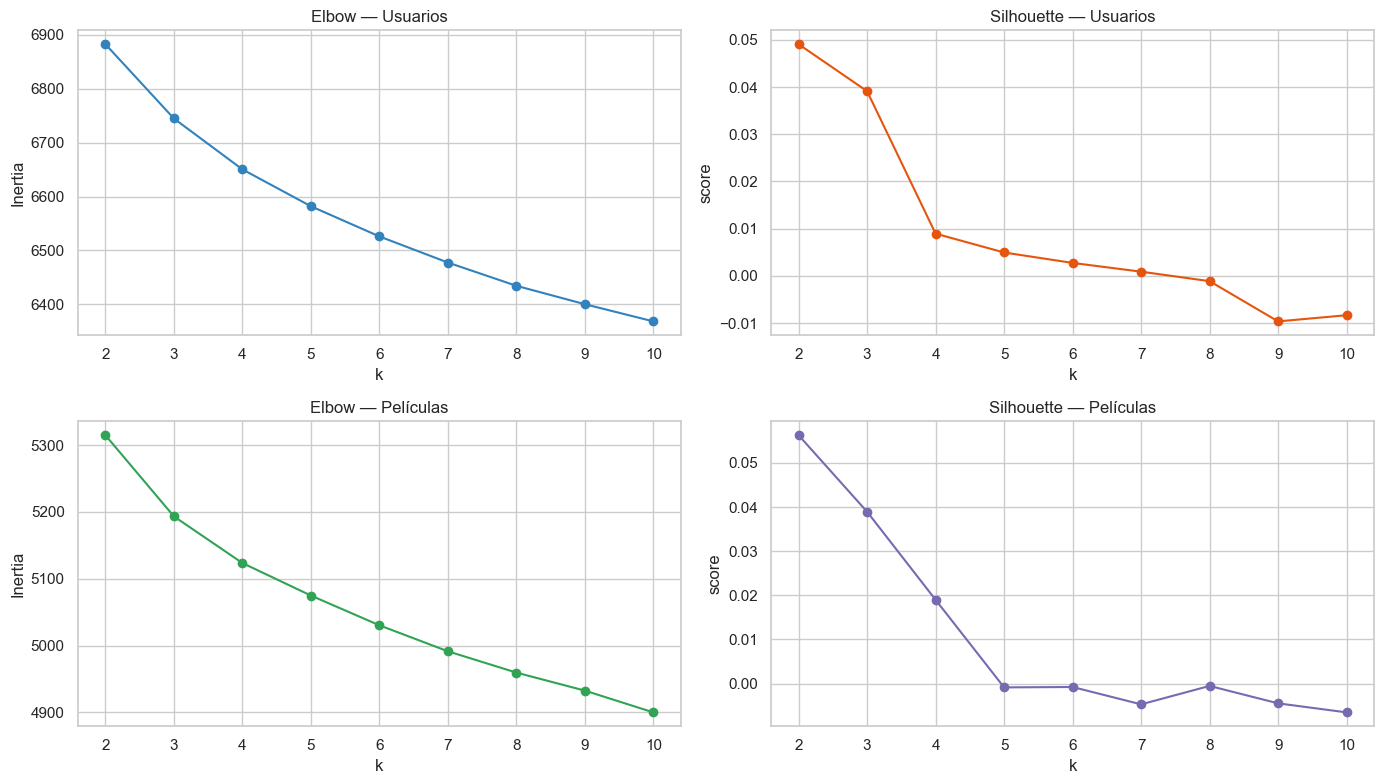

Usando K_USERS=6 y K_ITEMS=6 (configurables arriba en la sección de hiperparámetros).


In [25]:
# ============== ELBOW + SILHOUETTE PARA ELEGIR K ==============
k_range = list(range(2, 11))
inertias_u, silh_u = [], []
inertias_i, silh_i = [], []

rng = np.random.RandomState(SEED)
u_idx_sil = rng.choice(len(user_factors), size=min(4000, len(user_factors)), replace=False)
i_idx_sil = rng.choice(len(item_factors), size=min(4000, len(item_factors)), replace=False)

for k in k_range:
    km_u = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(user_factors)
    km_i = KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(item_factors)
    inertias_u.append(km_u.inertia_)
    inertias_i.append(km_i.inertia_)
    silh_u.append(silhouette_score(user_factors[u_idx_sil], km_u.labels_[u_idx_sil]))
    silh_i.append(silhouette_score(item_factors[i_idx_sil], km_i.labels_[i_idx_sil]))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0, 0].plot(k_range, inertias_u, 'o-', color='#3182bd'); axes[0, 0].set_title('Elbow — Usuarios'); axes[0, 0].set_xlabel('k'); axes[0, 0].set_ylabel('Inertia')
axes[0, 1].plot(k_range, silh_u,     'o-', color='#e6550d'); axes[0, 1].set_title('Silhouette — Usuarios'); axes[0, 1].set_xlabel('k'); axes[0, 1].set_ylabel('score')
axes[1, 0].plot(k_range, inertias_i, 'o-', color='#31a354'); axes[1, 0].set_title('Elbow — Películas'); axes[1, 0].set_xlabel('k'); axes[1, 0].set_ylabel('Inertia')
axes[1, 1].plot(k_range, silh_i,     'o-', color='#756bb1'); axes[1, 1].set_title('Silhouette — Películas'); axes[1, 1].set_xlabel('k'); axes[1, 1].set_ylabel('score')
plt.tight_layout(); plt.show()

print(f'Usando K_USERS={K_USERS_CLUSTERS} y K_ITEMS={K_ITEMS_CLUSTERS} (configurables arriba en la sección de hiperparámetros).')


In [26]:
# ============== KMEANS FINAL Y PERFILADO DE CLÚSTERES DE USUARIOS ==============
km_u_final = KMeans(n_clusters=K_USERS_CLUSTERS, random_state=SEED, n_init=10)
user_clusters = km_u_final.fit_predict(user_factors)

user_cluster_df = pd.DataFrame({
    'userId':  inner_to_raw_u.astype(np.int32),
    'cluster': user_clusters,
})

# Combinar con ratings y géneros para interpretar
tr_ratings = train_ratings_df.merge(user_cluster_df, on='userId', how='inner')
tr_ratings = tr_ratings.merge(movies[['movieId', 'genres']], on='movieId', how='left')

profiles = tr_ratings.groupby('cluster').agg(
    n_users=('userId', 'nunique'),
    n_ratings=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    std_rating=('rating', 'std'),
)
profiles['ratings_per_user'] = (profiles['n_ratings'] / profiles['n_users']).round(1)
print('Perfiles agregados por clúster de USUARIOS:')
print(profiles.round(3))

# Géneros top por clúster
def top_genres(df, topn=3):
    exploded = df.assign(genre=df['genres'].str.split('|')).explode('genre')
    return (exploded.groupby('genre')['rating']
            .agg(['count', 'mean'])
            .sort_values('count', ascending=False)
            .head(topn))

print('\nGéneros más consumidos por clúster (con su rating promedio):')
for c in sorted(tr_ratings['cluster'].unique()):
    top = top_genres(tr_ratings[tr_ratings['cluster'] == c])
    print(f'\n  Cluster {c} ({profiles.loc[c, "n_users"]} usuarios, rating_mean={profiles.loc[c, "avg_rating"]:.2f}):')
    for g, row in top.iterrows():
        print(f'    · {g:<20} n_votos={int(row["count"]):>7,}   rating_mean={row["mean"]:.2f}')


Perfiles agregados por clúster de USUARIOS:
         n_users  n_ratings  avg_rating  std_rating  ratings_per_user
cluster                                                              
0            707     148675       3.408       1.132             210.3
1           1919     146222       3.665       0.985              76.2
2           1251     184256       3.522       1.060             147.3
3           1867     180542       3.637       0.964              96.7
4           1598     151184       3.639       0.982              94.6
5            784     111180       3.608       1.075             141.8

Géneros más consumidos por clúster (con su rating promedio):

  Cluster 0 (707 usuarios, rating_mean=3.41):
    · Drama                n_votos= 71,408   rating_mean=3.65
    · Comedy               n_votos= 51,042   rating_mean=3.26
    · Thriller             n_votos= 41,373   rating_mean=3.36

  Cluster 1 (1919 usuarios, rating_mean=3.66):
    · Drama                n_votos= 70,910   rating_m

In [27]:
# ============== KMEANS FINAL Y PERFILADO DE CLÚSTERES DE PELÍCULAS ==============
km_i_final = KMeans(n_clusters=K_ITEMS_CLUSTERS, random_state=SEED, n_init=10)
item_clusters = km_i_final.fit_predict(item_factors)

item_cluster_df = pd.DataFrame({
    'movieId': inner_to_raw_i.astype(np.int32),
    'cluster': item_clusters,
}).merge(movies, on='movieId', how='left')

# Popularidad y rating medio por película (del trainset, coherente con los embeddings)
pop_by_movie = train_ratings_df.groupby('movieId').agg(
    n_ratings=('rating', 'count'),
    rating_mean=('rating', 'mean'),
).reset_index()
item_cluster_df = item_cluster_df.merge(pop_by_movie, on='movieId', how='left')

# Perfiles
item_profiles = item_cluster_df.groupby('cluster').agg(
    n_movies=('movieId', 'count'),
    avg_rating=('rating_mean', 'mean'),
    avg_popularity=('n_ratings', 'mean'),
    max_popularity=('n_ratings', 'max'),
).round(2)
print('Perfiles agregados por clúster de PELÍCULAS:')
print(item_profiles)

# Géneros dominantes y ejemplos representativos
print('\nEjemplos representativos por clúster (top-3 más populares de cada uno):')
for c in sorted(item_cluster_df['cluster'].unique()):
    sub = item_cluster_df[item_cluster_df['cluster'] == c].dropna(subset=['n_ratings']).sort_values('n_ratings', ascending=False)
    # Géneros dominantes
    g_exp = sub.assign(g=sub['genres'].str.split('|')).explode('g')
    top_g = g_exp['g'].value_counts().head(3).index.tolist()
    print(f'\n  Cluster {c} ({item_profiles.loc[c, "n_movies"]} películas, rating_mean={item_profiles.loc[c, "avg_rating"]:.2f}, '
          f'popularidad media={item_profiles.loc[c, "avg_popularity"]:.0f})')
    print(f'    géneros dominantes: {", ".join(top_g)}')
    for _, row in sub.head(3).iterrows():
        print(f'    ★ {row["title"]}  ({row["genres"]})  n={int(row["n_ratings"])}, avg={row["rating_mean"]:.2f}')


Perfiles agregados por clúster de PELÍCULAS:
         n_movies  avg_rating  avg_popularity  max_popularity
cluster                                                      
0            1437        3.57           89.98            2337
1             757        2.98          235.88            2000
2             334        3.55          462.95            2755
3             565        3.84          275.34            3150
4            1067        3.53          164.31            3268
5            1755        3.14           73.33            1529

Ejemplos representativos por clúster (top-3 más populares de cada uno):

  Cluster 0 (1437 películas, rating_mean=3.57, popularidad media=90)
    géneros dominantes: Drama, Comedy, Romance
    ★ Schindler's List (1993)  (Drama|War)  n=2337, avg=4.28
    ★ Willy Wonka & the Chocolate Factory (1971)  (Children|Comedy|Fantasy|Musical)  n=1143, avg=3.74
    ★ Rain Man (1988)  (Drama)  n=1126, avg=3.92

  Cluster 1 (757 películas, rating_mean=2.98, popularida

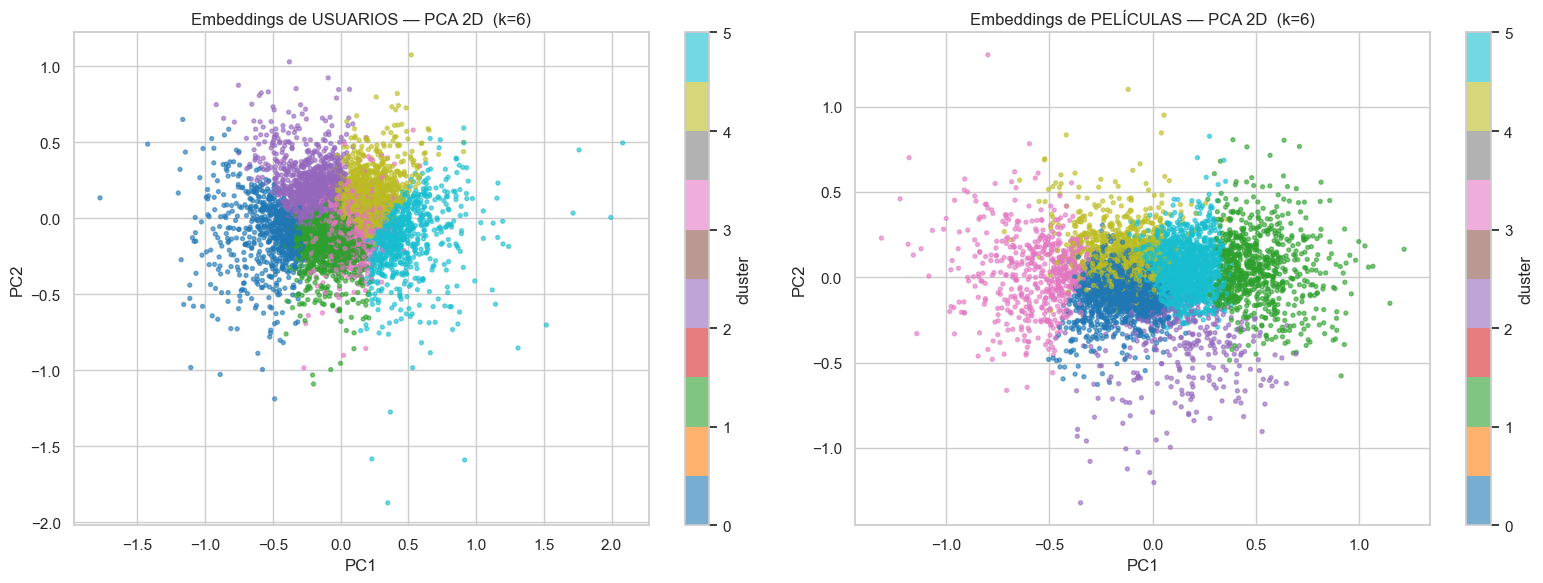

In [28]:
# ============== VISUALIZACIÓN PCA 2D DE CLÚSTERES ==============
pca_u = PCA(n_components=2, random_state=SEED).fit_transform(user_factors)
pca_i = PCA(n_components=2, random_state=SEED).fit_transform(item_factors)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(pca_u[:, 0], pca_u[:, 1], c=user_clusters, cmap='tab10', s=8, alpha=0.6)
axes[0].set_title(f'Embeddings de USUARIOS — PCA 2D  (k={K_USERS_CLUSTERS})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(sc1, ax=axes[0], label='cluster')

sc2 = axes[1].scatter(pca_i[:, 0], pca_i[:, 1], c=item_clusters, cmap='tab10', s=8, alpha=0.6)
axes[1].set_title(f'Embeddings de PELÍCULAS — PCA 2D  (k={K_ITEMS_CLUSTERS})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
plt.colorbar(sc2, ax=axes[1], label='cluster')

plt.tight_layout(); plt.show()


**Interpretación de clústeres (guía).**

Los clústeres de **usuarios** suelen segmentarse en perfiles como:
- *Críticos exigentes*: rating medio bajo (<3.5), varianza alta, consumen géneros nicho (Documentary, War).
- *Entusiastas*: rating medio alto (>4.0), pocos votos, mayormente blockbusters.
- *Cinéfilos balanceados*: rating medio ≈ global, muchísimos votos, todos los géneros.
- *Casuales*: pocos ratings, concentrados en Drama/Comedy mainstream.

Los clústeres de **películas** suelen separarse en:
- *Blockbusters universales* (alto rating + mucha popularidad).
- *Cine de nicho bien calificado* (alto rating + baja popularidad) → oro para **recomendaciones de descubrimiento**.
- *Contenido mainstream de rating medio* (volumen + rating ≈ 3.5).
- *Cola larga ruidosa* (pocos votos, dispersión alta).

Estos segmentos habilitan:
- **Recomendaciones segmentadas**: seleccionar candidatos dentro del mismo clúster del usuario activo.
- **Diversificación**: forzar que el Top-N cubra ≥ 2 clústeres distintos de películas.
- **Cold-start de usuario**: asignar al clúster más cercano según sus primeros 5-10 ratings.


## 10. Conclusiones y siguiente paso

| Hallazgo | Decisión para Fase 4 (Deep Learning) |
|---|---|
| SVD domina RMSE/NDCG con costo medio; KNN solo aporta interpretabilidad a alto costo. | Próximo modelo: **Neural Collaborative Filtering** (embeddings entrenados end-to-end) debería superar a SVD. |
| El *winner* de AutoML confirma que los hiperparámetros por defecto estaban cerca del óptimo (mejora marginal). | No invertir más ciclos en búsqueda clásica; priorizar **arquitecturas neuronales** con aprendizaje de features. |
| Clústeres de usuarios y películas son **interpretables y separables** en 2D. | Usar los clústeres como **features contextuales** del modelo DL (embedding + cluster_id como input). |
| Umbral de relevancia 4.0 es estable (sesgo positivo EDA). | Mantener ese umbral para todas las métricas de ranking en Fase 4. |
| Tiempo AutoML ≫ tiempos individuales → costo no lineal. | Para Fase 4 usar Optuna con *early stopping* por validation RMSE. |

### Siguientes notebooks
- `04_DeepLearning_Embeddings.ipynb` — NCF / Two-Tower con embeddings + los clústeres de este notebook como features categóricas.
- `05_Semantic_Search_RAG.ipynb` — buscador semántico sobre `tags` + `genome-scores`, re-ranker sobre los candidatos del SVD.


In [29]:
# ============== PERSISTENCIA DE ARTEFACTOS ==============
# Guardar modelos entrenados
with open(MODELS_DIR / 'svd_model.pkl', 'wb') as f:
    pickle.dump(svd, f)
with open(MODELS_DIR / 'knn_model.pkl', 'wb') as f:
    pickle.dump(knn, f)
with open(MODELS_DIR / 'nmf_model.pkl', 'wb') as f:
    pickle.dump(nmf, f)
with open(MODELS_DIR / 'baseline_scores.pkl', 'wb') as f:
    pickle.dump({
        'bayesian_score_by_movieId': score_dict,
        'global_mean_C': float(C),
        'm_prior': float(m),
    }, f)
with open(MODELS_DIR / 'automl_winner.pkl', 'wb') as f:
    pickle.dump({
        'model':   automl_model,
        'name':    best_name,
        'params':  best_params,
        'results': automl_results,
    }, f)

# Guardar asignaciones de clusters + tabla comparativa
user_cluster_df.to_parquet(REPORTS_DIR / 'user_clusters.parquet', index=False)
item_cluster_df.to_parquet(REPORTS_DIR / 'item_clusters.parquet', index=False)
comp_df.to_csv(REPORTS_DIR / 'model_comparison.csv', index=False)

print('Artefactos persistidos:')
for p in sorted(MODELS_DIR.glob('*.pkl')):
    print(f'   {p.relative_to(ROOT)}   ({p.stat().st_size/1024:.1f} KB)')
for p in sorted(REPORTS_DIR.glob('*')):
    if p.is_file():
        print(f'   {p.relative_to(ROOT)}   ({p.stat().st_size/1024:.1f} KB)')

gc.collect()
print('\nFase 3 completada.')


Artefactos persistidos:
   models/automl_winner.pkl   (25382.9 KB)
   models/baseline_scores.pkl   (71.6 KB)
   models/knn_model.pkl   (298720.3 KB)
   models/nmf_model.pkl   (27028.1 KB)
   models/svd_model.pkl   (30867.5 KB)
   reports/Proyecto.md   (12.0 KB)
   reports/README.md   (0.1 KB)
   reports/item_clusters.parquet   (216.8 KB)
   reports/model_comparison.csv   (0.9 KB)
   reports/user_clusters.parquet   (49.3 KB)

Fase 3 completada.
